# RadiantScan — Exploratory Data Analysis

## Phase 1: Dataset Exploration

This notebook performs initial exploratory data analysis (EDA) for the RadiantScan project.

### Goals
- Build a dataset manifest
- Check the number of images
- Analyze class distribution
- Measure class imbalance
- Check image dimensions
- Visualize sample chest X-rays

This analysis is performed before building the training pipeline.

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
from PIL import Image

from src.data_pipeline import (
    build_manifest,
    build_test_manifest,
    class_distribution
)

In [4]:
RAW_DIR = "../data/raw/chest_xray"

print("Dataset path:", RAW_DIR)

Dataset path: ../data/raw/chest_xray


In [5]:
df = build_manifest(RAW_DIR)
test_df = build_test_manifest(RAW_DIR)

print("Train + Validation images:", len(df))
print("Test images:", len(test_df))

Train + Validation images: 5232
Test images: 624


In [6]:
df.head()

,filepath,label,label_idx,source_split
0,..\data\raw\chest_xray\train\NORMAL\IM-0115-00...,NORMAL,0,train
1,..\data\raw\chest_xray\train\NORMAL\IM-0117-00...,NORMAL,0,train
2,..\data\raw\chest_xray\train\NORMAL\IM-0119-00...,NORMAL,0,train
3,..\data\raw\chest_xray\train\NORMAL\IM-0122-00...,NORMAL,0,train
4,..\data\raw\chest_xray\train\NORMAL\IM-0125-00...,NORMAL,0,train


In [7]:
dist = class_distribution(df)

print("Class distribution:")
print(dist)

Class distribution:
label
PNEUMONIA    3883
NORMAL       1349
Name: count, dtype: int64


In [8]:
imbalance_ratio = dist.max() / dist.min()

print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

Imbalance ratio: 2.88x


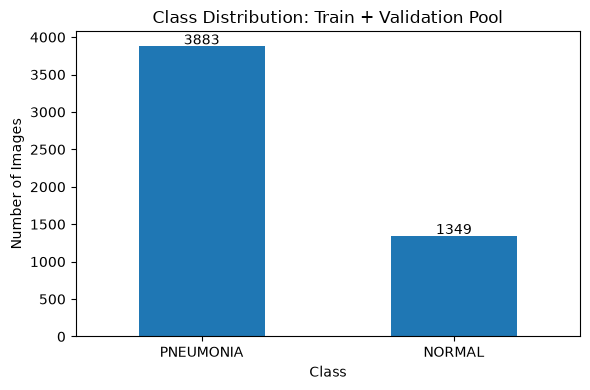

In [9]:
plt.figure(figsize=(6, 4))

dist.plot(kind="bar")

plt.title("Class Distribution: Train + Validation Pool")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

for i, value in enumerate(dist.values):
    plt.text(i, value + 20, str(value), ha="center")

plt.tight_layout()
plt.show()

In [10]:
test_dist = class_distribution(test_df)

print("Test class distribution:")
print(test_dist)

Test class distribution:
label
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


In [11]:
sizes = []

sample_df = df.sample(
    n=min(200, len(df)),
    random_state=42
)

for _, row in sample_df.iterrows():
    with Image.open(row["filepath"]) as img:
        sizes.append(img.size)

widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

print(
    f"Width  -> min: {min(widths)}, "
    f"max: {max(widths)}, "
    f"avg: {sum(widths)/len(widths):.0f}"
)

print(
    f"Height -> min: {min(heights)}, "
    f"max: {max(heights)}, "
    f"avg: {sum(heights)/len(heights):.0f}"
)

Width  -> min: 438, max: 2633, avg: 1328
Height -> min: 151, max: 2628, avg: 990


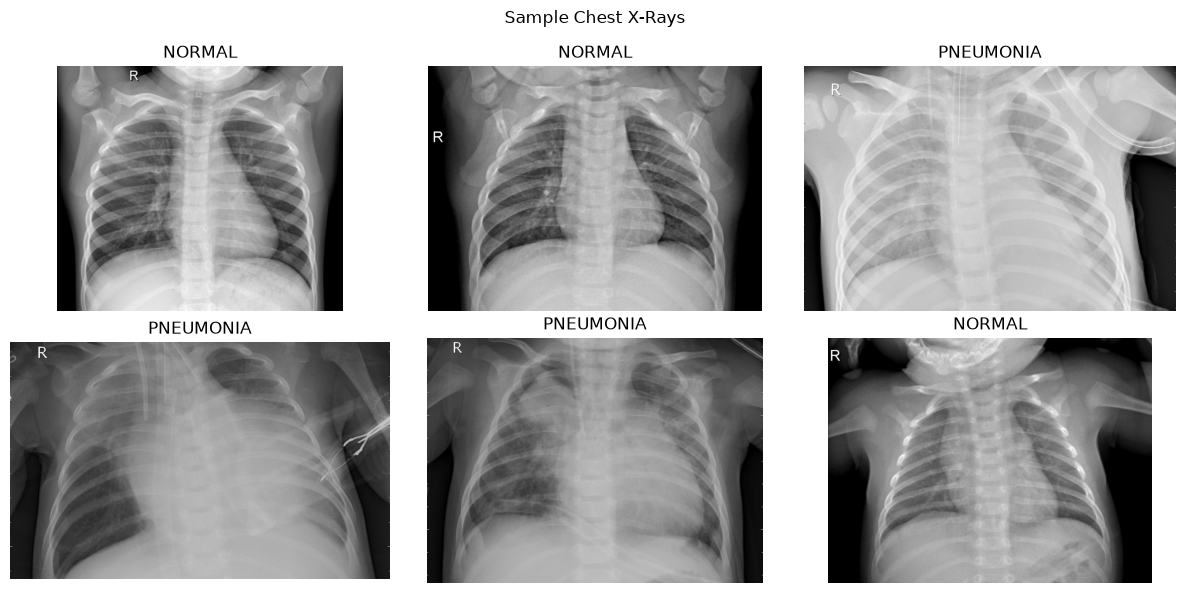

In [12]:
sample_df = df.sample(n=6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):

    img = Image.open(row["filepath"])

    ax.imshow(img, cmap="gray")
    ax.set_title(row["label"])
    ax.axis("off")

plt.suptitle("Sample Chest X-Rays")
plt.tight_layout()
plt.show()

In [13]:
modes = {}

for _, row in sample_df.iterrows():
    with Image.open(row["filepath"]) as img:
        modes[img.mode] = modes.get(img.mode, 0) + 1

print("Image modes in sample:")
print(modes)

Image modes in sample:
{'L': 6}


In [14]:
corrupted = []

for _, row in df.iterrows():

    try:
        with Image.open(row["filepath"]) as img:
            img.verify()

    except Exception:
        corrupted.append(row["filepath"])

print("Corrupted images:", len(corrupted))

if corrupted:
    print(corrupted[:10])

Corrupted images: 0
